# Prerequisites

- Technical
  - **Python programing**
  - **Numpy skills**
- Theoretical
  - **Linear Algebra & Geometry**: Understanding of vector spaces / $L^p$ norms (Euclidean vs Manhattan distance)/ dimentionality in feature spaces.
  - **Calculus**: Basic understanding of optimization (argmin, argmax operators).
  - **Statistics**:
    - **Descriptive statistics**: mode (for plurality voting) / mean (for regression).
    - **Probability**: class distributions / decision boundaries.

# Introduction

Before diving into the implementation, it is essential to understand where $k$NN algorithms sits in the landscape of ML.

## 1. What are NN algorithms?

Nearest Neighbor algorithms are among the simplest and most well-studied supervised learning methods in pattern recognition.

Unlike 'eager' algorithms that build a global model during training, all $k$NN does during the training phase is storing the dataset, this makes it a:

- **Lazy algorithm**: because it postpones all computations until prediction (inference).
- **non-parametric model**: because it makes no assumptions about the underlying form of the data.
- **Instance-based**: Predictions are made by comparing a new query point directly to the instances stored in memory.


## 2. What problem do they solve?

The primary challenge $k$NN addresses is **local function approximation**: technique that estimates a complex function using a simpler model (e.g. linear, Taylor polynomials...) restricted to a small neighborhood of the input space instead of the entire domain.

So instead of trying to find a complex formula that explains the dataset, $k$NN looks at the immediate vicinity of a query point. It assumes that similar points exist in close proximity; therefore, it approximates the target function locally by observing the $k$ most similar training examples. Which makes it a highly flexible and efficient **function approximator** and an excellent baseline benchmark for more complex models.

## 3. Real-world applications
- **Computer vision & Biometrics**: Identifying individuals based on extracted geometric features (e.g., facial recognition, fingerprint matching).
- **Recommender Systems**: Using "Collaborative filtering" to make suggestions based on the preferences of users with similar interests.
- **Outlier detection**: Identifiying data points that are 'lonely' in the feature space, which is useful for frauch detection.
- **Benchmarking**: Serving as a 'baseline' to see if more sophisticated models are providing significant performance boost.

## 4. When (and When Not) to Use $k$NN
| **Use $k$NN when...** | **Avoid $k$NN when...** |
| :--- | :--- |
| The dataset is small to medium-sized. | The dataset is massive (prediction becomes very slow). |
| You need a simple, interpretable baseline. | You have very high-dimensional data (The "Curse of Dimensionality"). |
| You don't want to make assumptions about data distribution. | Memory storage is a major constraint. |
| You want to capture complex, local patterns. | The data is very noisy or has many irrelevant features. |

# NN (Nearest Neighbor Algorithm)

The **Nearest Neighbor** algorithm is a classification model that makes a prediction by assigning the class label or continuous target value of **the most similar training example** to the query point.

## 1. Mathematical formulation
Let $x_q \in \mathbb{R}^d$ the point we want to classify or find a neighbor for, the goal here is to find $x^*$ for $x_q$ such that:
$$x^*=argmin_{x_i\in{D}}(d(x_i, x_q))$$

<center>$D$: training dataset.<br>
$x_i$: element from the training dataset.<br>
$x^*$: The most similar point to $x_q$.<br></center>

Unless denoted, the most used distance metrics of NN algorithms include:

- The Euclidean distance (also called $L^2$): $$d(x^{[a]}, x^{[b]}) = \sqrt{\sum_{i=1}^{m}(x_i^{[a]}-x_i^{[b]})^2}$$

- The Manhattan distance:

$$d(x^{[a]}, x^{[b]}) = \sum_{i=1}^{m}|x^{[a]}-x^{[b]}|$$

- A generalization of them both is the so-called Minkowski distance:

$$d(x^{[a]}, x^{[b]}) = (\sum_{i=1}^{m}(|x^{[a]}-x^{[b]}|)^p)^{\frac{1}{p}}$$

which is equal to the Euclidean distance

Where $p$ is a parameter that determins the type of the distance:
  - $p = 1$: $d(x^{[a]}, x^{[b]})$ is equal to the Manhattan distance.
  - $p = 2$: $d(x^{[a]}, x^{[b]})$ is equal to the Euclidian distance.
  - $p → ∞$: $d(x^{[a]}, x^{[b]})$ is equal to the Chebyshev distance, also known as chessboard distance, measures the maximum difference along any dimension.

## 2. Algorithm

Let: closest_point ← None, closest_distance ← ∞

for $i=1, ..., n$ in the $n$-dimentional training dataset $D(|D|=n)$:
  - current_distance ← $d(x_i, x_q)$
  - if current_distance < closest_distance:
    - closest_distance = current_distance
    - closest_point ← $x_i$

# KNN: $k$-Nearest Neighbor Classification and Regression

Now, instead of basing the prediction from the most similar training example, $k$NN considers the $k$ nearest neighbors when predicting a class label (in classification) or a continuous target value in regression.

## I. Classification

### 1. Majority vs Plurality

In k-NN classification, we look at the $k$ closest neighbors and assign a class label to the query point based on their labels $\{y_1, y_2, \dots, y_k\}$.

While often called "majority voting", the algorithm technically uses plurality voting.
  - **Majority**: Requires $> 50\%$ of the votes.
  - **Plurality**: Requires the mode (the most frequent value), even if it represents less than 50% of the total.
  
#### Example
in a 3-class setting ($k=10$):
  - Class A: 4 neighbors
  - Class B: 3 neighbors
  - Class C: 3 neighbors

Even though Class A only has 40% of the votes (not a majority), it is the plurality winner. The model predicts Class A.

### 2. Mathematical Formulation

In $k$NN classification we run plurality voting among the $k$ nearest neighbors.
Assume we have a target function $f(x) = y$ that assigns a class label $y \in \{i,\dots,t\}$ to a training example:
$$f: \mathbb{R}^d → \{1, \dots,t\}$$

And assuming we identified the $k$ nearest neighbors of a query point $x^{[q]}$:
$$D_k = \{(x^{[1]}, f(x^{[1]})),\dots,(x^{[k]}, f(x^{[k]}))\}$$

The $k$NN hypothesis is defined as finding the label $y$ that maximizes the sum of a Kroneker Delta function:
$$h(x^{[q]})=argmax_{y\in\{i,\dots,t\}}\sum_{i=1}^{k}\delta(y, f(x^{[i]}))$$

$$\delta(a, b) = \begin{cases} 1, & \text{if } a=b \\ 0, &\text{if } a \neq b
\end{cases}$$

or using the $mode$ which identifies the most frequent value in dataset:
$$h(x^{[q]}) = mode(\{f(x^{[1]}),\dots,f(x^{[k]})\})$$

## II. Regression

The general concept of $k$NN for regression is the same as for classification, we first find the $k$ nearest neighbors, then we make a prediction based on the labels of the $k$ nearest neighbors. Except that in regression, the target function is a real application instead of discrete-valued function:
$$f: \mathbb{R}^d → \mathbb{R}  \ d\in\mathbb{N}^{*+}$$

By calculating the $mean$ of the neighbors target values, the following hypothesis function predicts a continuous value that represents the class to which belongs $x^{[q]}$:

$$h(x^{[q]})=\frac{1}{k}\sum_{i=1}^{k}y_i$$

- $y_i$: the numerical property value of the $i$-th neighbor.

## III. Computational Performance

### 1. Big O of Naive $k$NN

for the brute-force neighbor search of the $k$NN algorithm, the time complexity is $O(n × m)$, where $n$ is the number of training examples and $m$ is the number of dimensions in the training dataset.

### 2. Approaches to improve computational performance

#### i. Using a [Priority Queue](https://en.wikipedia.org/wiki/Priority_queue)

Instead of sorting the entire distance array -which would take $O(nlog(n))$- we can use a **Max-Heap** of size $k$:
- We maintain the $k$ closest points found so far.
- If a new point is closer than the 'farthest' point in our heap, we swap them.
- this reduces the search complexity to $O(nlog(k))$, which is significantly faster when $k ≪ n$

#### ii. Specialized Data structures (Space patitioning)
Instead of a "Brute force" search, we can organize the data into structures that allow to skip large insignificant portions of the search space:

- **Bucketing**: Dividing the space into a fixed grid of cells.
- **KD-Trees**: A binary tree that partitions the space using axis-aligned hyperplanes. It workds exceptionally well for low-dimentional data ($O(log n)$ average case).
- **Ball-trees**: Partitions data into nested hyperspheres. These are more computationally expensive to build than KD-Trees but perform better in higher-dimentional spaces.

#### iii. Data Reduction & Pruning

We can reduce the amount of data the algorithm has to "look at" before we even start the search:

- **Dimensionality Reduction**: Using techniques like **PCA (Principal Component Analysis)** or **Feature Selection** to reduce $d$. Fewer features mean "cheaper" distance calculations.
- **Editing**: Permanently removing "useless" data points, such as outliers that don't affect the decision boundary or points deep inside a class cluster that don't help define the edge.
- **Prototypes**: Replacing a dense cluster of many points with a single "prototype" point (centroid) that represents them all.

#### iv. Hardware Acceleration

$k$NN is a highly parallelizable algorithm. Since the distance calculation for one neighbor is independent of the others, we can speedup the process by:

- **Parallel Processing**: Distributing distance calculations across multiple CPU cores or using **GPUs** for massive vectorization.

- **Distributed Computing**: Using frameworks like Map-Reduce to split the training set across multiple machines.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

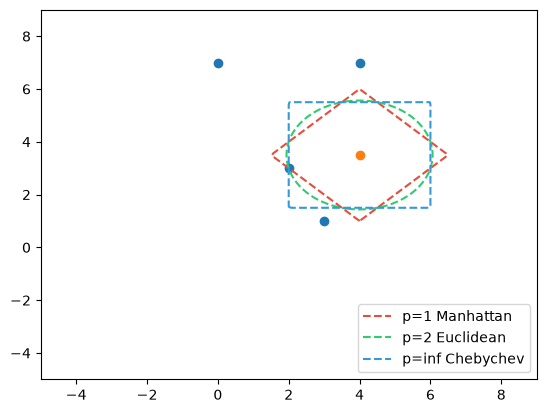

In [2]:
# Visualizing the difference between distance measurement metrics

def dist(x1, x2, p = 2):
  if p == np.inf:
    return np.max(np.abs(x1 - x2), axis=1)
  return np.power(
      np.sum(np.power(np.abs(x1 - x2), p), axis=1),
      1/p
      )

x_test = np.array([[2, 3], [4, 7], [0, 7], [3, 1]])
y_test = np.random.randint(0, 1, x_test.shape[1])
x_q = np.array([[4, 3.5]])

p_values = [1, 2, np.inf]
colors = ['#e74c3c', '#2ecc71', '#3498db']
labels = ["p=1 Manhattan", "p=2 Euclidean", "p=inf Chebychev"]

x_range = np.linspace(min(x_test[:, 0]) - 5, max(x_test[:, 0]) + 5, 200)
y_range = np.linspace(min(x_test[:, 1]) - 5, max(x_test[:, 1]) + 5, 200)
xx, yy = np.meshgrid(x_range, y_range)
grid_points = np.c_[xx.ravel(), yy.ravel()]

plt.xlim(min(x_test[:, 0]) - 5, max(x_test[:, 0]) + 5)
plt.ylim(min(x_test[:, 0]) - 5, max(x_test[:, 0]) + 5)

plt.scatter(x_test[:, 0], x_test[:, 1])
plt.scatter(x_q[0,0], x_q[0,1])

for i, p in enumerate(p_values):
  dists = dist(x_test, x_q, p)
  min_dist = dists[np.argmin(dists)]

  grid_dists = dist(grid_points, x_q, p=p)
  grid_dists = grid_dists.reshape(xx.shape)

  contour = plt.contour(xx, yy, grid_dists, levels=[min_dist], colors=colors[i], linestyles='--')
  plt.plot([], [], color=colors[i], linestyle='--', label=labels[i])

plt.legend(loc='lower right')

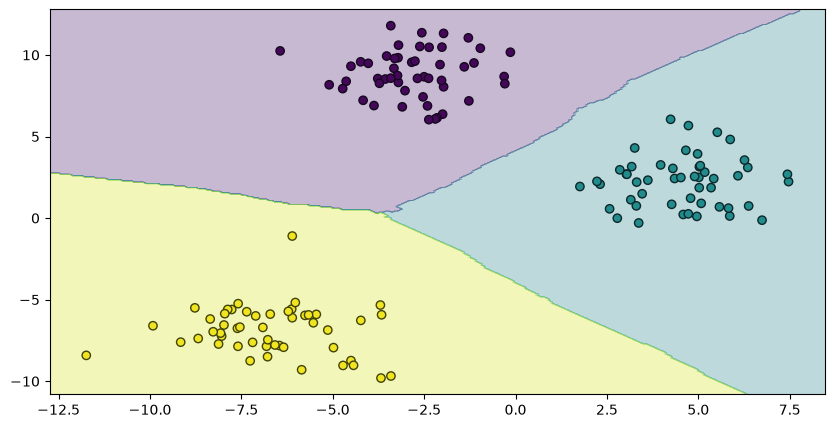

In [3]:
from ml_from_scratch.classification.knn import KNNClassifier, KNNRegressor

X, Y = make_blobs(n_samples=150, n_features=2, centers=3, cluster_std=1.5, random_state=42)

model = KNNClassifier(k=10)
model.fit(X, Y)

h = .08
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))

Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

fig = plt.figure(figsize=(10, 5))
ax = fig.add_subplot()
ax.scatter(X[:, 0], X[:, 1], c=Y, edgecolors='k')
ax.contourf(xx, yy, Z, alpha=0.3)

# Resources

https://sebastianraschka.com/pdf/lecture-notes/stat479fs18/02_knn_notes.pdf